# Notebook 03 — Drought Indicator Construction

This notebook constructs three standardized drought indices for Afghanistan's 399 districts (2000–2025):

| Index | Full Name | Source Variable | Measures |
|-------|-----------|-----------------|----------|
| VCI | Vegetation Condition Index | NDVI | Vegetation health relative to historical range |
| TCI | Temperature Condition Index | LST | Thermal stress relative to historical range |
| SPI-3 | Standardized Precipitation Index (3-month) | Rainfall | Precipitation anomalies using gamma distribution |

Key steps: Data quality assessment → Gap interpolation → Baseline climatology (2001–2020) → Index calculation → Quality flagging

Outputs - Intermediate indicator dataset and fitted distribution parameters:

`vci_parameters.csv` 

`tci_parameters.csv` 

`spi_gamma_parameters.csv` 

`afg_indicators_2000_2025.csv` 

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.stats import norm, gamma
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt

In [32]:
# Project Paths
PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT / "data" / "raw"

In [33]:
# Baseline period for all climatology computation
baseline_start = 2001
baseline_end = 2020

## Data Loading

Load the raw climate dataset and prepare helper columns for temporal aggregation. The dataset contains monthly observations of NDVI, LST, and rainfall for each district.

In [34]:
# Load raw data
df_raw = pd.read_csv(data_dir / "afg_climate_2000_2025.csv")
#print(df_raw.head())

# df with columns of interest
cols = ["ADM2_CODE", "ADM2_NAME", "ADM1_NAME", "date", "NDVI", "LST", "RAIN"]
df = df_raw[cols].copy()

df["date"] = pd.to_datetime(df["date"])
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nUnique districts: {df['ADM2_CODE'].nunique()}")
print(f"\nDtypes:\n{df.dtypes}")

# Helper columns
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Check for duplicates
assert not df.duplicated(["ADM2_CODE", "date"]).any(), \
    "Duplicate rows found for (ADM2_CODE, date)"

print(f"\nShape: {df.shape}")
print(f"\n{df.head()}")

Date range: 2000-03-01 00:00:00 to 2025-11-01 00:00:00

Unique districts: 399

Dtypes:
ADM2_CODE             int64
ADM2_NAME            object
ADM1_NAME            object
date         datetime64[ns]
NDVI                float64
LST                 float64
RAIN                float64
dtype: object

Shape: (123291, 9)

   ADM2_CODE               ADM2_NAME ADM1_NAME       date      NDVI  \
0      99888                   Kakar     Zabul 2000-03-01  0.098077   
1      99889                Nawbahar     Zabul 2000-03-01  0.076697   
2      99890                  Waghaz    Ghazni 2000-03-01  0.087726   
3      99891  Walimuhammad-e- Shahid    Ghazni 2000-03-01  0.095729   
4      99892                 Jaghatu    Ghazni 2000-03-01  0.103345   

         LST       RAIN  year  month  
0  19.669000  33.851074  2000      3  
1  30.243096  27.608813  2000      3  
2  23.778092  38.718642  2000      3  
3  22.635478  44.207202  2000      3  
4  17.127572  39.010399  2000      3  


## Missing Data Investigation

Assess data completeness across variables. Missing values result from quality masks applied during extraction (cloud cover, snow, low-quality pixels). LST has negligible missingness; NDVI has ~0.44% missing observations.

In [35]:
# Overall Missing Data
print("Missing Data:\n")
VARS = ["NDVI", "LST", "RAIN"]
missing_table = (
    df[VARS].agg([
        lambda x: x.isna().sum(), "count", lambda x: x.isna().mean() * 100
    ]).T)

missing_table.columns = ["missing", "total obs", "% missing"]
missing_table = missing_table.round(2)
print(missing_table.to_string())

Missing Data:

      missing  total obs  % missing
NDVI    535.0   122756.0       0.43
LST      37.0   123254.0       0.03
RAIN      0.0   123291.0       0.00


## NDVI Missing Data Analysis

Investigate the spatial and temporal patterns of missing NDVI. Results show that 99.8% of missing observations occur in January–February, concentrated in high-elevation districts where winter cloud cover and snow are prevalent. This confirms the quality masking is working as expected.

In [36]:
# Seasonal pattern of missing NDVI
print("Seasonal Pattern of Missing NDVI:\n")
ndvi_by_month = df.groupby("month").agg({
    "NDVI": [lambda x: x.isna().sum(), "count", lambda x: x.isna().mean()*100]
})
ndvi_by_month.columns = ["missing", "total obs", "% missing"]
ndvi_by_month = ndvi_by_month.round(2)
print(ndvi_by_month.to_string())

Seasonal Pattern of Missing NDVI:

       missing  total obs  % missing
month                               
1          322       9653       3.23
2          212       9763       2.13
3            0      10374       0.00
4            0      10374       0.00
5            0      10374       0.00
6            0      10374       0.00
7            0      10374       0.00
8            0      10374       0.00
9            0      10374       0.00
10           0      10374       0.00
11           0      10374       0.00
12           1       9974       0.01


In [37]:
# District-level pattern of missing NDVI 
print("District quality distribution (% missing NDVI):\n")

def pct_missing(s): 
    return s.isna().mean() * 100

district = (
    df.groupby(["ADM2_CODE", "ADM2_NAME", "ADM1_NAME"], as_index=False)
      .agg(
          pct_missing_ndvi=("NDVI", pct_missing),
          pct_missing_lst=("LST", pct_missing),
          missing_count=("NDVI", lambda s: s.isna().sum())
      )
)

# Quality classification based on % missing NDVI
def label_quality(r):
    if r.pct_missing_ndvi == 0:
        return "Number of districts EXCELLENT (0%)"
    if r.pct_missing_ndvi < 5:
        return "Number of districts GOOD (<5%)"
    if r.pct_missing_ndvi < 10:
        return "Number of districts MODERATE (5-10%)"
    return "Number of districts PROBLEMATIC (>10%)"

district["data_quality"] = district.apply(label_quality, axis=1)
print(district["data_quality"].value_counts())

District quality distribution (% missing NDVI):

data_quality
Number of districts EXCELLENT (0%)        284
Number of districts GOOD (<5%)            110
Number of districts MODERATE (5-10%)        4
Number of districts PROBLEMATIC (>10%)      1
Name: count, dtype: int64


In [38]:
print("Top 10 districts by % missing NDVI:\n")
print(district.sort_values("pct_missing_ndvi", ascending=False)
      .head(10)[["ADM2_NAME", "ADM1_NAME", "pct_missing_ndvi"]]
      .to_string(index=False))

Top 10 districts by % missing NDVI:

             ADM2_NAME  ADM1_NAME  pct_missing_ndvi
                Panjab     Bamyan         10.032362
      Lal Wa Sarjangal       Ghor          7.119741
       Markaz-e-Behsud     Wardak          5.825243
              Shighnan Badakhshan          5.501618
             Dawlatyar       Ghor          5.177994
              Kohestan Badakhshan          4.854369
                Paryan   Panjsher          4.530744
Hesa-e- Awal-e- Behsud     Wardak          4.530744
                Darwaz Badakhshan          3.883495
               Shuhada Badakhshan          3.883495


In [39]:
# NDVI Gap Length Distribution
m = df.sort_values(["ADM2_CODE", "date"])["NDVI"].isna()

run_id = (
    m.groupby(df["ADM2_CODE"])
     .apply(lambda s: s.ne(s.shift()).cumsum()).reset_index(level=0, drop=True))

run_len = (
    df.groupby([df["ADM2_CODE"], run_id])["NDVI"].transform("size"))

gap_counts = run_len[m].value_counts().sort_index()

one = int(gap_counts.get(1, 0))
two = int(gap_counts.get(2, 0))
gt2 = int(gap_counts[gap_counts.index > 2].sum())

print("NDVI Gap Length Distribution (missing observations):\n"
    f"\n1-month gaps:   {one:,}\n"
    f"2-month gaps:   {two:,}\n"
    f">2-month gaps:  {gt2:,}\n"
    f"Total:          {int(m.sum()):,}")

NDVI Gap Length Distribution (missing observations):

1-month gaps:   311
2-month gaps:   224
>2-month gaps:  0
Total:          535


## Interpolation for Missing NDVI and LST

Fill small gaps using time-based linear interpolation within each district. Since all gaps are ≤2 consecutive months, interpolation is applied without additional gap detection.

- **Method:** Pandas time-based interpolation (`limit=2`, `limit_area="inside"`)
- **New columns:** `NDVI_filled`, `LST_filled` (interpolated values)
- **Flags:** `NDVI_was_filled`, `LST_was_filled` (boolean indicators for transparency)

In [40]:
# Sort by district and date
df = df.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)
# Store original NaN masks
ndvi_was_nan = df["NDVI"].isna().copy()
lst_was_nan = df["LST"].isna().copy()
# Time-based interpolation per district
def interpolate_district(grp):
    """Interpolate NDVI and LST using time-based method for a single district."""
    # Set date as index for time-based interpolation
    grp = grp.set_index("date")
    
    # Interpolate NDVI
    grp["NDVI_filled"] = grp["NDVI"].interpolate(
        method="time",
        limit=2,
        limit_area="inside"
    )
    
    # Interpolate LST
    grp["LST_filled"] = grp["LST"].interpolate(
        method="time",
        limit=2,
        limit_area="inside"
    )
    
    grp = grp.reset_index()
    return grp
# Apply interpolation per district and re-sort for consistent ordering
df = df.groupby("ADM2_CODE", group_keys=False).apply(interpolate_district)
df = df.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)
# Create boolean flags for filled values
# True only where original was NaN AND filled is not NaN
df["NDVI_was_filled"] = ndvi_was_nan & df["NDVI_filled"].notna()
df["LST_was_filled"] = lst_was_nan & df["LST_filled"].notna()

/var/folders/z6/z1n0171120j96ppkmzrykt7c0000gn/T/ipykernel_9026/564054185.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("ADM2_CODE", group_keys=False).apply(interpolate_district)


---
# Drought Indicator Construction

This section computes three complementary drought indices using a **2001–2020 baseline period** for climatological reference. Each index is scaled to enable comparison and eventual combination into a composite drought index.

In [41]:
# Constants
# Percentiles for robust min/max (VCI/TCI)
PERCENTILE_LOW = 5    # p05
PERCENTILE_HIGH = 95  # p95

## VCI (Vegetation Condition Index)

VCI measures current vegetation health relative to the historical range for each district-month combination:

$$\text{VCI} = 100 \times \frac{\text{NDVI}_{\text{current}} - \text{NDVI}_\text{min}}{\text{NDVI}_\text{max} - \text{NDVI}_\text{min}}$$

- **Range:** 0 (worst observed) to 100 (best observed)
- **Climatology:** 5th and 95th percentiles used for robust min/max estimation

In [42]:
# Filter baseline period
baseline_mask = (df["year"] >= baseline_start) & (df["year"] <= baseline_end)
df_baseline = df[baseline_mask].copy()

# Compute NDVI percentiles per district-month
vci_params = df_baseline.groupby(["ADM2_CODE", "month"]).agg(
    NDVI_p05=("NDVI_filled", lambda x: np.nanpercentile(x, PERCENTILE_LOW)),
    NDVI_p95=("NDVI_filled", lambda x: np.nanpercentile(x, PERCENTILE_HIGH)),
    NDVI_baseline_count=("NDVI_filled", "count"),
    NDVI_baseline_mean=("NDVI_filled", "mean")
).reset_index()

# Merge parameters back to main dataframe
df = df.merge(vci_params, on=["ADM2_CODE", "month"], how="left")

# Compute VCI
df["VCI"] = 100 * (df["NDVI_filled"] - df["NDVI_p05"]) / (df["NDVI_p95"] - df["NDVI_p05"])

# Create clipped version for analysis and flag values outside 0-100 range
df["VCI_clipped"] = df["VCI"].clip(0, 100)
df["VCI_out_of_range"] = (df["VCI"] < 0) | (df["VCI"] > 100)

print(f"  VCI computed for {df['VCI'].notna().sum():,} observations")
print(f"  VCI missing: {df['VCI'].isna().sum():,}")

  VCI computed for 123,291 observations
  VCI missing: 0


VCI SANITY CHECKS

Distribution:
count    123291.00
mean         50.75
std          36.78
min        -430.52
50%          50.49
max         333.90
Name: VCI, dtype: float64

Range checks:
   VCI in [0, 100]: 107,374 (87.1%)
   VCI < 0   : 7,386 (6.0%)
   VCI > 100 : 8,531 (6.9%)

VCI Histogram:


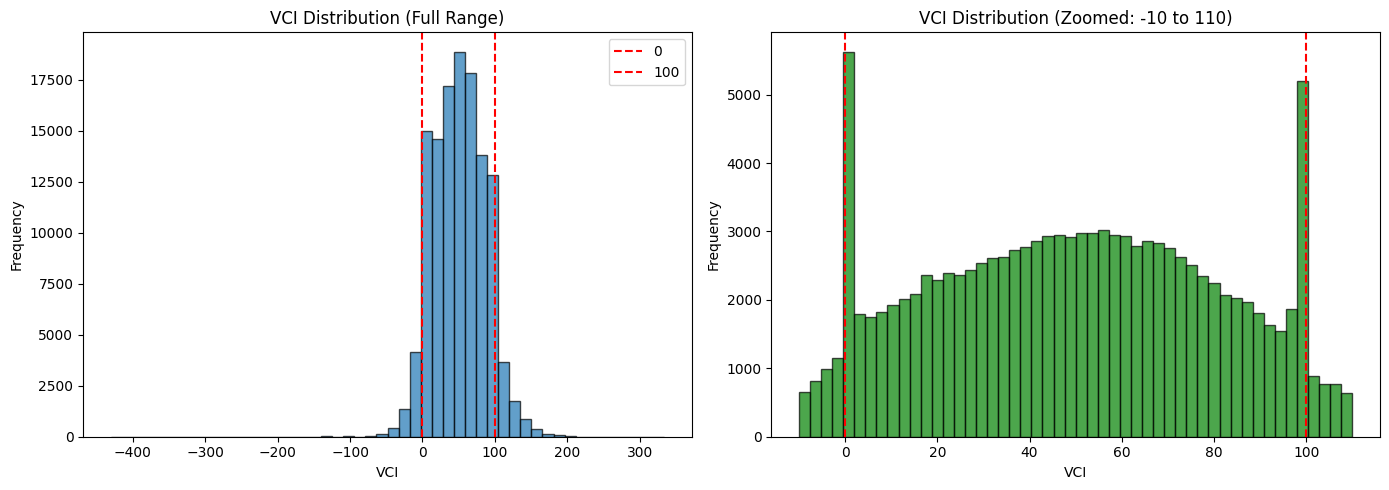

In [43]:
# VCI Sanity Checks
print("VCI SANITY CHECKS")

vci = df["VCI"].dropna()
n = len(vci)

# Summary stats
print("\nDistribution:")
print(vci.describe()[["count", "mean", "std", "min", "50%", "max"]].round(2))

# Range checks
counts = {
    "VCI in [0, 100]": ((vci >= 0) & (vci <= 100)).sum(),
    "VCI < 0": (vci < 0).sum(),
    "VCI > 100": (vci > 100).sum(),
}

print("\nRange checks:")
for label, c in counts.items():
    print(f"   {label:<10}: {c:,} ({c/n*100:.1f}%)")

# Histogram of VCI
print("\nVCI Histogram:")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full range
axes[0].hist(vci, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='0')
axes[0].axvline(x=100, color='red', linestyle='--', label='100')
axes[0].set_xlabel('VCI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('VCI Distribution (Full Range)')
axes[0].legend()

# Zoomed (0-100 range)
vci_zoomed = vci[(vci >= -10) & (vci <= 110)]
axes[1].hist(vci_zoomed, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].axvline(x=100, color='red', linestyle='--')
axes[1].set_xlabel('VCI')
axes[1].set_ylabel('Frequency')
axes[1].set_title('VCI Distribution (Zoomed: -10 to 110)')

plt.tight_layout()
plt.show()

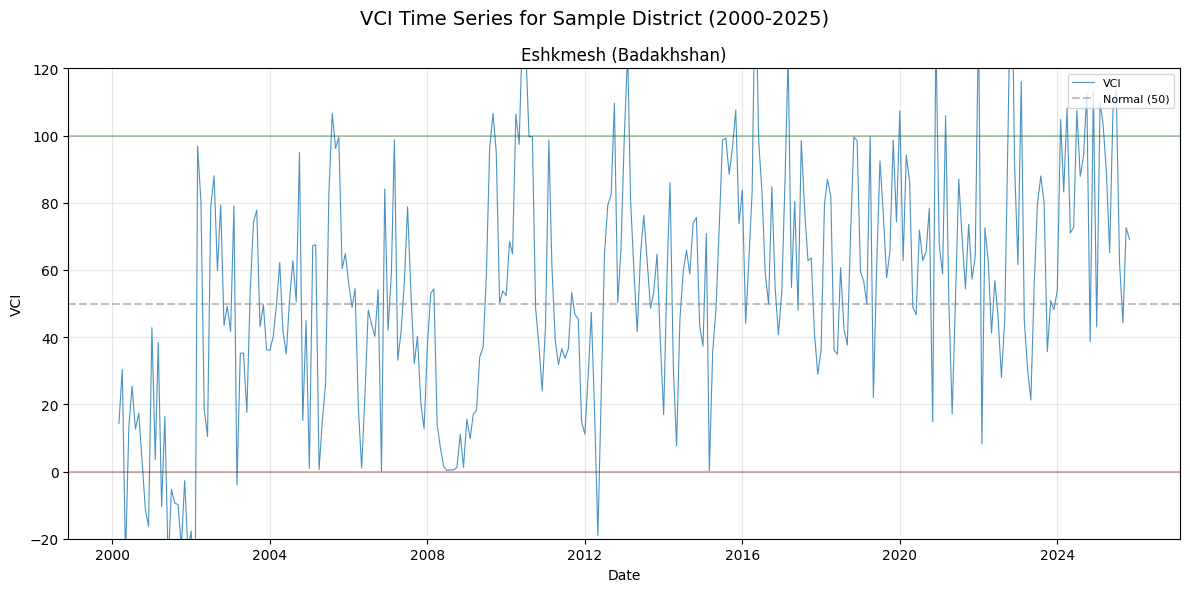

In [44]:
# VCI time series for a sample district

# Select sample district (iloc[0])
adm2_code = df.groupby("ADM1_NAME")["ADM2_CODE"].first().iloc[0]

d = df.loc[df["ADM2_CODE"] == adm2_code].sort_values("date")
district_name = d["ADM2_NAME"].iat[0]
province_name = d["ADM1_NAME"].iat[0]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(d["date"], d["VCI"], linewidth=0.8, alpha=0.8, label="VCI")
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Normal (50)')
ax.axhline(y=0, color='darkred', linestyle='-', alpha=0.3)
ax.axhline(y=100, color='darkgreen', linestyle='-', alpha=0.3)

ax.set(xlabel="Date", ylabel="VCI", title=f"{district_name} ({province_name})", ylim=(-20, 120))
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("VCI Time Series for Sample District (2000-2025)", fontsize=14)
fig.tight_layout()
plt.show()

## TCI (Temperature Condition Index)

TCI measures thermal stress, where **higher LST indicates worse conditions** (inverted relationship):

$$\text{TCI} = 100 \times \frac{\text{LST}_\text{max} - \text{LST}_{\text{current}}}{\text{LST}_\text{max} - \text{LST}_\text{min}}$$

- **Range:** 0 (hottest/worst) to 100 (coolest/best)
- **Climatology:** 5th and 95th percentiles for robust min/max

In [45]:
# Compute LST percentiles per district-month
tci_params = df_baseline.groupby(["ADM2_CODE", "month"]).agg(
    LST_p05=("LST_filled", lambda x: np.nanpercentile(x, PERCENTILE_LOW)),
    LST_p95=("LST_filled", lambda x: np.nanpercentile(x, PERCENTILE_HIGH)),
    LST_baseline_count=("LST_filled", "count"),
    LST_baseline_mean=("LST_filled", "mean")
).reset_index()

# Merge parameters back to main dataframe
df = df.merge(tci_params, on=["ADM2_CODE", "month"], how="left")

# Compute TCI (inverted formula)
# Higher LST = worse conditions, so we invert: LST_p95 - LST_current
df["TCI"] = 100 * (df["LST_p95"] - df["LST_filled"]) / (df["LST_p95"] - df["LST_p05"])

# Create clipped version for analysis
df["TCI_clipped"] = df["TCI"].clip(0, 100)

# Flag values outside 0-100 range
df["TCI_out_of_range"] = (df["TCI"] < 0) | (df["TCI"] > 100)

print(f"  TCI computed for {df['TCI'].notna().sum():,} observations")
print(f"  TCI missing: {df['TCI'].isna().sum():,}")

  TCI computed for 123,291 observations
  TCI missing: 0


TCI SANITY CHECKS

Distribution:
count    123291.00
mean         51.73
std          42.01
min        -180.02
50%          48.97
max         487.37
Name: TCI, dtype: float64

Range checks:
   TCI in [0, 100]: 104,535 (84.8%)
   TCI < 0   : 7,838 (6.4%)
   TCI > 100 : 10,918 (8.9%)

Pearson correlation (VCI, TCI): 0.237


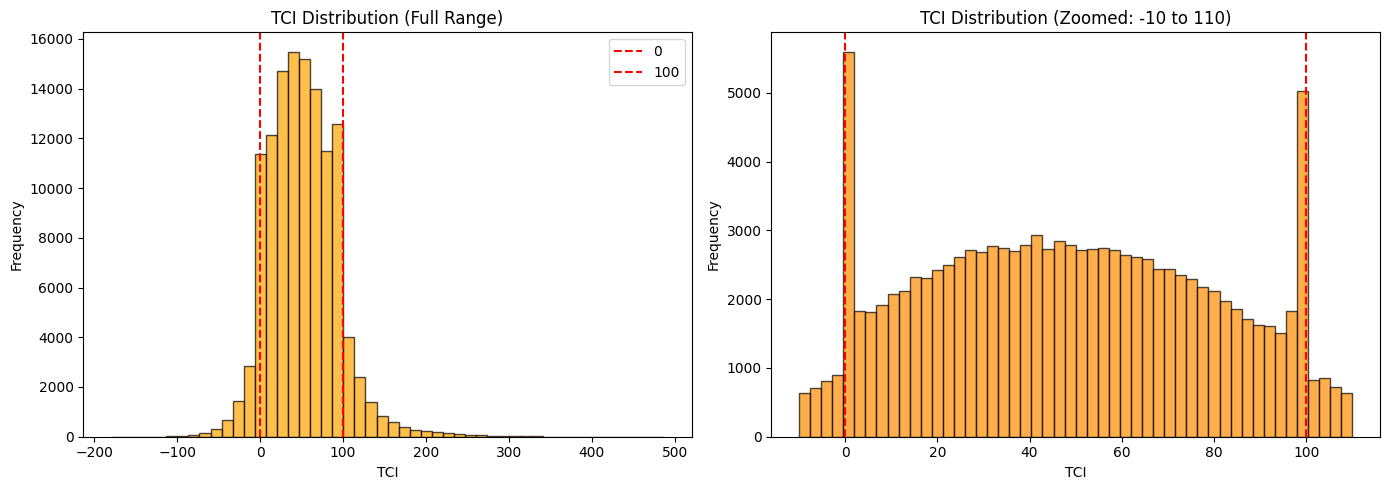

In [46]:
# TCI Sanity Checks
print("TCI SANITY CHECKS")

tci = df["TCI"].dropna()
n = len(tci)

# Summary stats
print("\nDistribution:")
print(tci.describe()[["count", "mean", "std", "min", "50%", "max"]].round(2))

# Range checks
counts = {
    "TCI in [0, 100]": ((tci >= 0) & (tci <= 100)).sum(),
    "TCI < 0": (tci < 0).sum(),
    "TCI > 100": (tci > 100).sum(),
}

print("\nRange checks:")
for label, c in counts.items():
    print(f"   {label:<10}: {c:,} ({c/n*100:.1f}%)")

# VCI-TCI correlation
valid_both = df[["VCI", "TCI"]].dropna()
correlation = valid_both["VCI"].corr(valid_both["TCI"])
print(f"\nPearson correlation (VCI, TCI): {correlation:.3f}")

# Histogram of TCI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full range
axes[0].hist(tci, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(x=0, color='red', linestyle='--', label='0')
axes[0].axvline(x=100, color='red', linestyle='--', label='100')
axes[0].set_xlabel('TCI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('TCI Distribution (Full Range)')
axes[0].legend()

# Zoomed (0-100 range)
tci_zoomed = tci[(tci >= -10) & (tci <= 110)]
axes[1].hist(tci_zoomed, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].axvline(x=100, color='red', linestyle='--')
axes[1].set_xlabel('TCI')
axes[1].set_ylabel('Frequency')
axes[1].set_title('TCI Distribution (Zoomed: -10 to 110)')

plt.tight_layout()
plt.show()

## SPI-3 (Standardized Precipitation Index, 3-month)

SPI quantifies precipitation anomalies by fitting historical data to a gamma distribution and transforming to a standard normal scale:

**Computation steps:**
1. Compute 3-month rolling precipitation sums per district
2. Fit gamma distribution to baseline period (2001–2020) for each district-month
3. Transform to standard normal: $\text{SPI} = \Phi^{-1}(\text{Gamma CDF}(P))$

**Interpretation:**
| SPI Value | Category |
|-----------|----------|
| ≥ 2.0 | Extremely wet |
| 1.0 to 2.0 | Moderately wet |
| -1.0 to 1.0 | Near normal |
| -1.0 to -2.0 | Moderate drought |
| ≤ -2.0 | Severe/extreme drought |

In [47]:
# SPI rolling window (months)
SPI_K = 3

In [48]:
# SPI-3 - Step 1: Rolling Sum Computation

# Sort by district and date
df = df.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)

# Compute rolling 3-month precipitation sum per district
def compute_rolling_precip(grp):
    """Compute 3-month rolling sum of precipitation for a district."""
    grp = grp.sort_values("date")
    grp["RAIN_3m"] = grp["RAIN"].rolling(window=SPI_K, min_periods=SPI_K).sum()
    return grp

df = df.groupby("ADM2_CODE", group_keys=False).apply(compute_rolling_precip)
df = df.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)

/var/folders/z6/z1n0171120j96ppkmzrykt7c0000gn/T/ipykernel_9026/358298086.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("ADM2_CODE", group_keys=False).apply(compute_rolling_precip)


In [49]:
# SPI-3 - Step 2: Fit Gamma Distribution per District-Month

# Filter baseline period with valid RAIN_3m
baseline_rain = df[(df["year"] >= baseline_start) & (df["year"] <= baseline_end) & df["RAIN_3m"].notna()].copy()

# Epsilon for edge cases
EPS = 1e-10

def fit_gamma_for_spi(rain_values):
    """
    Fit gamma distribution to precipitation data, handling zeros.
    Returns: (shape, loc, scale, zero_prob, n_obs, fit_success)
    
    Mixed distribution:
    - P(X=0) = q (probability of zero)
    - P(X>0) follows gamma distribution
    """
    rain_arr = np.array(rain_values)
    rain_arr = rain_arr[~np.isnan(rain_arr)]
    n_obs = len(rain_arr)
    
    if n_obs < 5:  # minimum observations
        return np.nan, np.nan, np.nan, np.nan, n_obs, False
    
    # Calculate zero probability
    n_zeros = (rain_arr == 0).sum()
    zero_prob = n_zeros / n_obs
    
    # Get non-zero values for gamma fitting
    rain_positive = rain_arr[rain_arr > 0]
    
    if len(rain_positive) < 3:  # Need at least 3 positive values
        return np.nan, np.nan, np.nan, zero_prob, n_obs, False
    
    try:
        # Fit gamma distribution to positive values only
        # Using method of moments as starting point, then MLE
        shape, loc, scale = gamma.fit(rain_positive, floc=0)
        
        # Validate parameters
        if shape <= 0 or scale <= 0 or np.isnan(shape) or np.isnan(scale):
            return np.nan, np.nan, np.nan, zero_prob, n_obs, False
            
        return shape, loc, scale, zero_prob, n_obs, True
        
    except Exception as e:
        return np.nan, np.nan, np.nan, zero_prob, n_obs, False

# Fit gamma for each district-month combination
gamma_params_list = []
district_months = baseline_rain.groupby(["ADM2_CODE", "month"])

for (adm2, month), grp in district_months:
    shape, loc, scale, zero_prob, n_obs, success = fit_gamma_for_spi(grp["RAIN_3m"])
    gamma_params_list.append({
        "ADM2_CODE": adm2,
        "month": month,
        "gamma_shape": shape,
        "gamma_loc": loc,
        "gamma_scale": scale,
        "zero_prob": zero_prob,
        "n_baseline_obs": n_obs,
        "gamma_fit_success": success
    })

gamma_params = pd.DataFrame(gamma_params_list)

# Summary
n_success = gamma_params["gamma_fit_success"].sum()
n_failed = (~gamma_params["gamma_fit_success"]).sum()
print(f"\nGamma fitting results:")
print(f"  Total district-month combinations: {len(gamma_params):,}")
print(f"  Successful fits: {n_success:,} ({n_success/len(gamma_params)*100:.1f}%)")
print(f"  Failed fits: {n_failed:,} ({n_failed/len(gamma_params)*100:.1f}%)")

# Show sample parameters
print("\nSample gamma parameters (first 5 successful fits):")
print(gamma_params[gamma_params["gamma_fit_success"]].head(5).to_string(index=False))


Gamma fitting results:
  Total district-month combinations: 4,788
  Successful fits: 4,769 (99.6%)
  Failed fits: 19 (0.4%)

Sample gamma parameters (first 5 successful fits):
 ADM2_CODE  month  gamma_shape  gamma_loc  gamma_scale  zero_prob  n_baseline_obs  gamma_fit_success
      3448      1     7.326792        0.0    11.119886        0.0              20               True
      3448      2     7.935184        0.0    14.712417        0.0              20               True
      3448      3     9.715367        0.0    15.606235        0.0              20               True
      3448      4    13.851279        0.0    12.910367        0.0              20               True
      3448      5    13.149423        0.0    12.539222        0.0              20               True


In [50]:
# SPI-3 - Step 3: Calculate SPI Values

# Merge gamma parameters to main dataframe
df = df.merge(
    gamma_params[["ADM2_CODE", "month", "gamma_shape", "gamma_scale", "zero_prob", "gamma_fit_success"]],
    on=["ADM2_CODE", "month"],
    how="left"
)

def compute_spi(row):
    """
    Compute SPI for a single observation using fitted gamma parameters.
    Handles zeros using mixed distribution approach.
    """
    rain_3m = row["RAIN_3m"]
    shape = row["gamma_shape"]
    scale = row["gamma_scale"]
    zero_prob = row["zero_prob"]
    fit_success = row["gamma_fit_success"]
    
    # Return NaN if missing data or failed fit
    if pd.isna(rain_3m) or not fit_success or pd.isna(shape) or pd.isna(scale):
        return np.nan
    
    # Handle zero precipitation
    if rain_3m == 0:
        # Use half the zero probability for zeros (standard approach)
        prob = zero_prob / 2
    else:
        # Cumulative probability from gamma CDF for non-zero values
        # P(X <= x) = P(X=0) + P(0 < X <= x) = q + (1-q)*gamma_cdf(x)
        gamma_cdf_val = gamma.cdf(rain_3m, shape, loc=0, scale=scale)
        prob = zero_prob + (1 - zero_prob) * gamma_cdf_val
    
    # Bound probability to avoid infinite SPI values
    prob = np.clip(prob, EPS, 1 - EPS)
    
    # Transform to standard normal (SPI)
    spi = norm.ppf(prob)
    
    return spi


df["SPI"] = df.apply(compute_spi, axis=1)

# Summary
spi_valid = df["SPI"].notna().sum()
spi_missing = df["SPI"].isna().sum()

print(f"Valid SPI values: {spi_valid:,}")
print(f"Missing SPI values: {spi_missing:,}")
print(f"    - Due to rolling window (first 2 months): ~{df['ADM2_CODE'].nunique() * 2:,}")
print(f"    - Due to failed gamma fits: ~{spi_missing - df['ADM2_CODE'].nunique() * 2:,}")

Valid SPI values: 121,999
Missing SPI values: 1,292
    - Due to rolling window (first 2 months): ~798
    - Due to failed gamma fits: ~494


In [51]:
# SPI-3 Sanity Checks
print("SPI-3 Sanity Checks")

# SPI distribution
print("\nSPI distribution analysis")
spi_valid_vals = df["SPI"].dropna()
print(f"   Valid SPI observations: {len(spi_valid_vals):,}")
print(f"   Mean: {spi_valid_vals.mean():.4f} ")
print(f"   Std:  {spi_valid_vals.std():.4f} ")
print(f"   Min:  {spi_valid_vals.min():.2f}")
print(f"   Max:  {spi_valid_vals.max():.2f}")

# Extreme values
print("\nExtreme SPI value check")
extreme_low = (spi_valid_vals < -3).sum()
extreme_high = (spi_valid_vals > 3).sum()
pct_extreme = (extreme_low + extreme_high) / len(spi_valid_vals) * 100

print(f"   SPI < -3: {extreme_low:,} ({extreme_low/len(spi_valid_vals)*100:.2f}%)")
print(f"   SPI > 3:  {extreme_high:,} ({extreme_high/len(spi_valid_vals)*100:.2f}%)")

# SPI vs RAIN correlation check
print("\nSPI vs RAIN correlation check")
valid_both_spi = df[["SPI", "RAIN_3m"]].dropna()
spi_rain_corr = valid_both_spi["SPI"].corr(valid_both_spi["RAIN_3m"])
print(f"   Pearson correlation (SPI, RAIN_3m): {spi_rain_corr:.3f}")

SPI-3 Sanity Checks

SPI distribution analysis
   Valid SPI observations: 121,999
   Mean: -0.0975 
   Std:  1.0354 
   Min:  -6.36
   Max:  6.36

Extreme SPI value check
   SPI < -3: 191 (0.16%)
   SPI > 3:  116 (0.10%)

SPI vs RAIN correlation check
   Pearson correlation (SPI, RAIN_3m): 0.288


## SPI Missingness Investigation

SPI has two sources of missing values:

1. **Rolling window initialization:** The first 2 months of each district's time series are undefined (removed below)
2. **Gamma fit failures:** Systematic missingness in September for 19 arid districts where July–September precipitation is near-zero, causing unstable gamma fits

These 19 districts are flagged for transparency but represent a small fraction of total observations.

In [52]:
# View a sample district's SPI to see first two month NaNs due to rolling window
sample_adm2 = df["ADM2_CODE"].iloc[0]
sample_spi = df[df["ADM2_CODE"] == sample_adm2][["date", "SPI"]].sort_values("date").head(5)
print("Sample District SPI values, first two months should be NaN:")
print(sample_spi.to_string(index=False))

Sample District SPI values, first two months should be NaN:
      date       SPI
2000-03-01       NaN
2000-04-01       NaN
2000-05-01 -1.093319
2000-06-01 -0.883220
2000-07-01 -0.284350


In [53]:
# Filter out first 2 months per district 
print("Filtering first 2 months per district:")

# Sort by district and date
n_districts = df["ADM2_CODE"].nunique()
df = df.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)

# Create a row number within each district and filter out first 2 months (keep row_num >= 3)
df["row_num"] = df.groupby("ADM2_CODE").cumcount() + 1
df = df[df["row_num"] >= 3].copy()

# Drop temporary row number column
df = df.drop(columns=["row_num"])

print(f"   Dropped {n_districts * 2:,} rows corresponding to first 2 months per district.")

Filtering first 2 months per district:
   Dropped 798 rows corresponding to first 2 months per district.


In [54]:
# Check if remaining missing SPI is systematic
has_spi = df["SPI"].notna()
no_spi = (~has_spi)

missing_spi = df[no_spi]
print(f"Observations with missing SPI: {len(missing_spi):,}\n")
print(f"Districts affected: {missing_spi['ADM2_CODE'].nunique()}\n")
print(f"Months affected:\n{missing_spi['month'].value_counts().sort_index()}\n")

Observations with missing SPI: 494

Districts affected: 19

Months affected:
month
9    494
Name: count, dtype: int64



In [55]:
# All missing SPI was found to be in September
# Which districts are affected?
print(f"Districts with missing SPI (September) and their counts:\n")
print(missing_spi.groupby(["ADM1_NAME", "ADM2_NAME"]).size().sort_values(ascending=False).head(20))

Districts with missing SPI (September) and their counts:

ADM1_NAME  ADM2_NAME        
Badghis    Qala-e-Naw           26
Farah      Shibkoh              26
Takhar     Khwajabahawuddin     26
Nimroz     Khashrod             26
Hirat      Herat                26
Ghor       Saghar               26
           Charsadra            26
Faryab     Qorghan              26
           Khan-e-Char Bagh     26
Farah      Qala-e-Kah           26
Balkh      Sharak-e-Hayratan    26
Farah      Pushtrod             26
           Purchaman            26
           Khak-e-Safed         26
           Gulestan             26
           Farah                26
           Balabuluk            26
           Bakwa                26
Uruzgan    Shahid-e-Hassas      26
dtype: int64


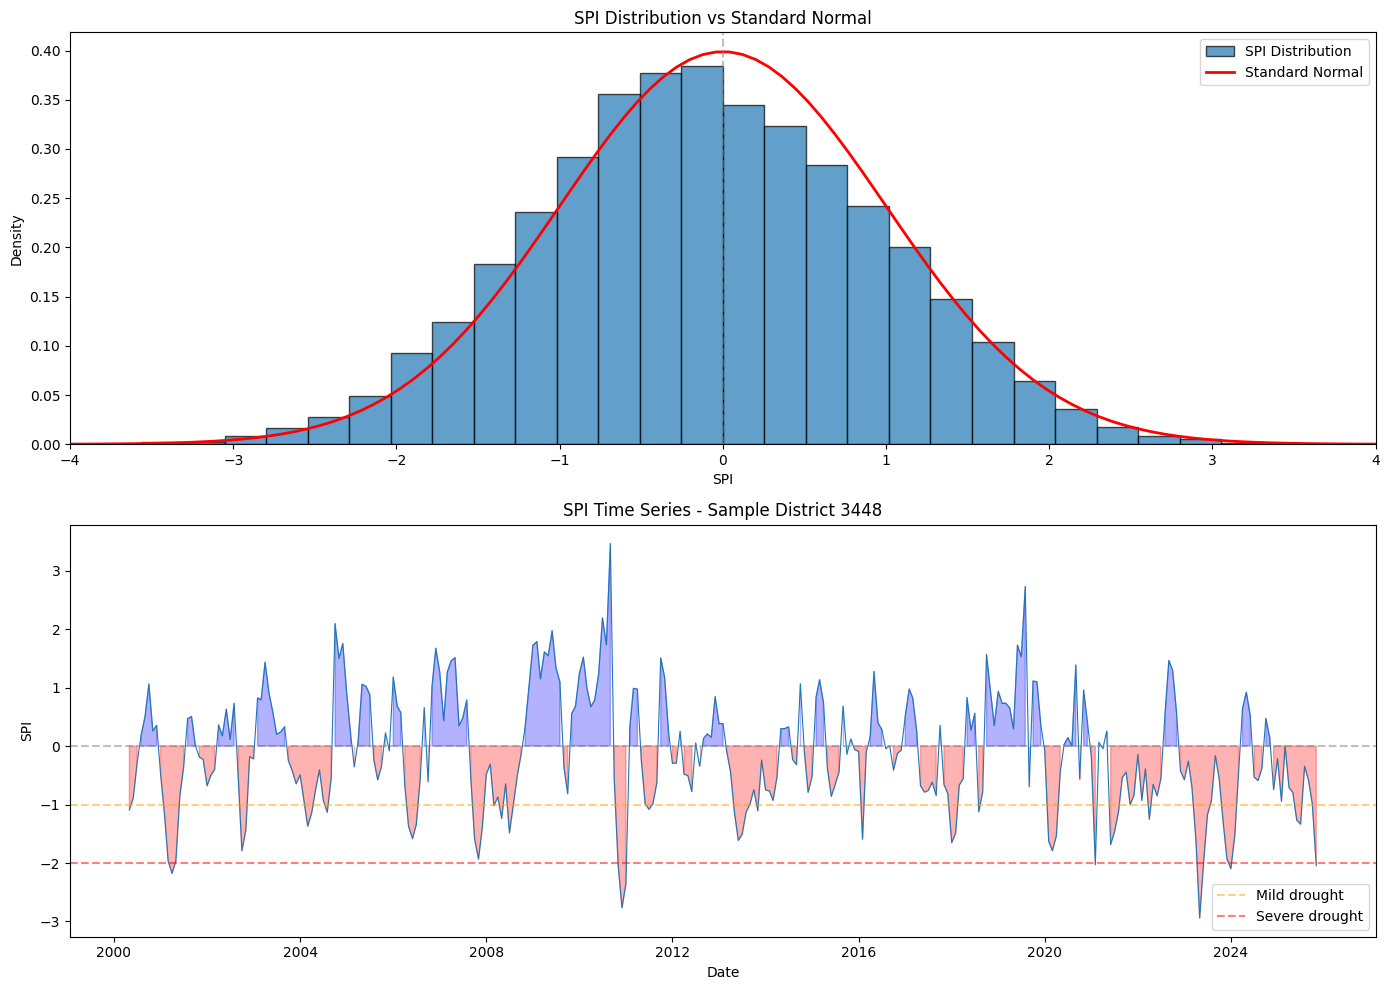

In [ ]:
# SPI Distribution and Time Series Visuals

# SPI Histogram with normal overlay
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
spi_vals = df["SPI"].dropna()
ax1.hist(spi_vals, bins=50, density=True, alpha=0.7, edgecolor='black', label='SPI Distribution')
x_range = np.linspace(-4, 4, 100)
ax1.plot(x_range, norm.pdf(x_range), 'r-', lw=2, label='Standard Normal')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('SPI')
ax1.set_ylabel('Density')
ax1.set_title('SPI Distribution vs Standard Normal')
ax1.legend()
ax1.set_xlim(-4, 4)

# SPI time series for sample district
ax2 = axes[1]
sample_district_spi = df["ADM2_CODE"].iloc[0]
district_spi_data = df[df["ADM2_CODE"] == sample_district_spi].sort_values("date")
ax2.plot(district_spi_data["date"], district_spi_data["SPI"], linewidth=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=-1, color='orange', linestyle='--', alpha=0.5, label='Mild drought')
ax2.axhline(y=-2, color='red', linestyle='--', alpha=0.5, label='Severe drought')
ax2.fill_between(district_spi_data["date"], district_spi_data["SPI"], 0, 
                  where=district_spi_data["SPI"] < 0, alpha=0.3, color='red')
ax2.fill_between(district_spi_data["date"], district_spi_data["SPI"], 0,
                  where=district_spi_data["SPI"] >= 0, alpha=0.3, color='blue')
ax2.set_xlabel('Date')
ax2.set_ylabel('SPI')
ax2.set_title(f'SPI Time Series - Sample District {sample_district_spi}')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
# Data Quality Flags

Compile quality flags for each observation for transparency and reproducibility:

| Flag | Description |
|------|-------------|
| `NDVI_was_filled` | NDVI value was interpolated (original masked) |
| `LST_was_filled` | LST value was interpolated |
| `VCI_out_of_range` | VCI outside 0–100 (extreme conditions) |
| `TCI_out_of_range` | TCI outside 0–100 (extreme conditions) |
| `SPI_gamma_fit_failed` | Gamma distribution fit failed for this district-month |

A spatial map visualizes the geographic distribution of flagged observations.

Data Quality Flags Compilation

Flag                           Count    Percent

NDVI_was_filled                  535      0.44%
LST_was_filled                    37      0.03%
VCI_out_of_range              15,721     12.83%
TCI_out_of_range              18,364     14.99%
SPI_gamma_fit_failed             494      0.40%
any_quality_flag              30,849     25.18%


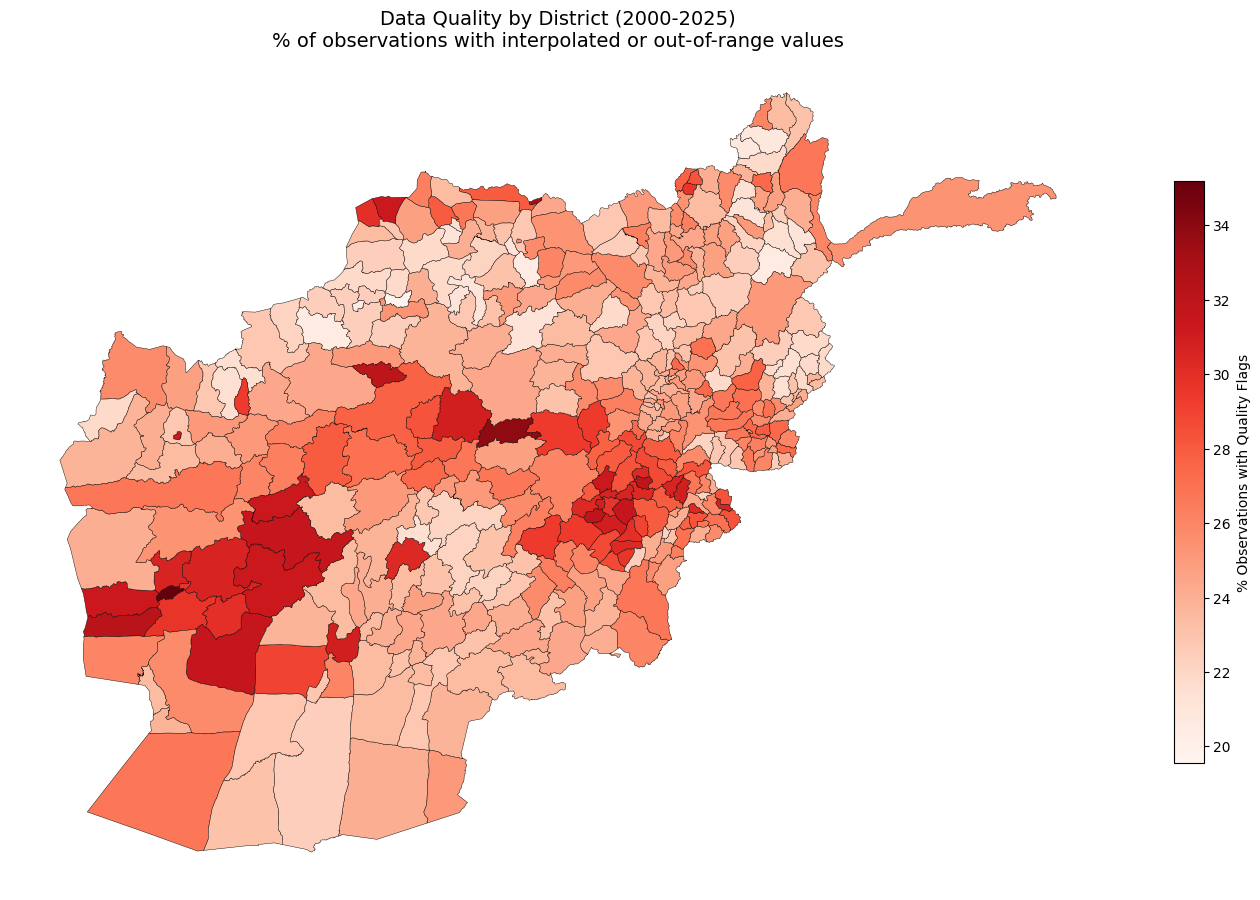


Data Quality Summary - Top 5 Districts with Most Quality Flags:

        ADM2_NAME ADM1_NAME  n_total  pct_ndvi_filled  pct_vci_oor  pct_tci_oor  pct_any_flag
         Pushtrod     Farah      307              0.0         18.6         16.0          35.2
           Panjab    Bamyan      307             10.1         15.0         16.0          33.9
Sharak-e-Hayratan     Balkh      307              0.0         14.0         16.3          33.2
          Shibkoh     Farah      307              0.0         12.4         16.0          32.2
           Waghaz    Ghazni      307              2.0         19.9         15.3          31.9


In [57]:
# Data Quality Flags + District Map 
print("Data Quality Flags Compilation")

# flags
df["SPI_gamma_fit_failed"] = ~df["gamma_fit_success"].fillna(False)

quality_flags = [
    "NDVI_was_filled",
    "LST_was_filled",
    "VCI_out_of_range",
    "TCI_out_of_range",
    "SPI_gamma_fit_failed",
]

df["any_quality_flag"] = df[quality_flags].any(axis=1)

# summary print
print(f"\n{'Flag':<25} {'Count':>10} {'Percent':>10}\n")
for f in quality_flags + ["any_quality_flag"]:
    s = df[f]
    print(f"{f:<25} {int(s.sum()):>10,} {s.mean()*100:>9.2f}%")

# district map 
districts_gdf = gpd.read_file(PROJECT_ROOT / "data" / "raw" / "afg_district_lookup.geojson")

# percent columns to compute (means * 100)
pct_cols = {
    "NDVI_was_filled": "pct_ndvi_filled",
    "LST_was_filled": "pct_lst_filled",
    "VCI_out_of_range": "pct_vci_oor",
    "TCI_out_of_range": "pct_tci_oor",
    "any_quality_flag": "pct_any_flag",
}

quality_stats = (
    df.groupby(["ADM2_CODE", "ADM2_NAME", "ADM1_NAME"])
      .agg(
          n_total=("date", "count"),
          date_min=("date", "min"),
          date_max=("date", "max"),
          **{out: (col, lambda x: x.mean() * 100) for col, out in pct_cols.items()},
      )
      .reset_index()
)

quality_gdf = districts_gdf[["ADM2_CODE", "geometry"]].merge(quality_stats, on="ADM2_CODE", how="left")

fig, ax = plt.subplots(figsize=(14, 10))
quality_gdf.plot(
    column="pct_any_flag",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "% Observations with Quality Flags", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

ax.set_title(
    "Data Quality by District (2000-2025)\n% of observations with interpolated or out-of-range values",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()
plt.show()

# top 5 table + date range
cols_show = ["ADM2_NAME", "ADM1_NAME", "n_total", "pct_ndvi_filled", "pct_vci_oor", "pct_tci_oor", "pct_any_flag"]
print("\nData Quality Summary - Top 5 Districts with Most Quality Flags:\n")
print(quality_stats.nlargest(5, "pct_any_flag")[cols_show].round(1).to_string(index=False))

In [58]:
# Final summary of drought indices
print("\nFinal Drought Indices Summary:\n")
print(f"{'Index':<8} {'Valid':>12} {'Missing':>12} {'Mean':>10} {'Std':>10}\n")


for idx_name in ["VCI", "TCI", "SPI"]:
    valid = df[idx_name].notna().sum()
    missing = df[idx_name].isna().sum()
    mean = df[idx_name].mean()
    std = df[idx_name].std()
    print(f"{idx_name:<8} {valid:>12,} {missing:>12,} {mean:>10.2f} {std:>10.2f}")


Final Drought Indices Summary:

Index           Valid      Missing       Mean        Std

VCI           122,493            0      50.94      36.75
TCI           122,493            0      52.08      41.75
SPI           121,999          494      -0.10       1.04


In [59]:
# Save intermediate outputs

# Save VCI/TCI parameters and gamma parameters for reference
interim_dir = PROJECT_ROOT / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)

# Save VCI parameters
vci_params_path = interim_dir / "vci_parameters.csv"
vci_params.to_csv(vci_params_path, index=False)

# Save TCI parameters
tci_params_path = interim_dir / "tci_parameters.csv"
tci_params.to_csv(tci_params_path, index=False)

# Save SPI gamma parameters
spi_params_path = interim_dir / "spi_gamma_parameters.csv"
gamma_params.to_csv(spi_params_path, index=False)

# Save main indicators dataset
indicators_path = interim_dir / "afg_indicators_2000_2025.csv"
df.to_csv(indicators_path, index=False)